In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [175]:
data = pd.read_csv(r"C:\Users\umesh\Downloads\archive (4)\train.csv", encoding='ISO-8859-1', header=0)
print(data.head())

       textID                                               text  \
0  cb774db0d1                I`d have responded, if I were going   
1  549e992a42      Sooo SAD I will miss you here in San Diego!!!   
2  088c60f138                          my boss is bullying me...   
3  9642c003ef                     what interview! leave me alone   
4  358bd9e861   Sons of ****, why couldn`t they put them on t...   

                         selected_text sentiment Time of Tweet Age of User  \
0  I`d have responded, if I were going   neutral       morning        0-20   
1                             Sooo SAD  negative          noon       21-30   
2                          bullying me  negative         night       31-45   
3                       leave me alone  negative       morning       46-60   
4                        Sons of ****,  negative          noon       60-70   

       Country  Population -2020  Land Area (Km²)  Density (P/Km²)  
0  Afghanistan          38928346         652860.0    

In [177]:
data.head()

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346,652860.0,60
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797,27400.0,105
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044,2381740.0,18
3,9642c003ef,what interview! leave me alone,leave me alone,negative,morning,46-60,Andorra,77265,470.0,164
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,noon,60-70,Angola,32866272,1246700.0,26


In [179]:
data.shape

(27481, 10)

# virtual working

In [182]:
data['sentiment'].value_counts()

sentiment
neutral     11118
positive     8582
negative     7781
Name: count, dtype: int64

In [184]:
print(data.columns)

Index(['textID', 'text', 'selected_text', 'sentiment', 'Time of Tweet',
       'Age of User', 'Country', 'Population -2020', 'Land Area (Km²)',
       'Density (P/Km²)'],
      dtype='object')


<Axes: xlabel='sentiment'>

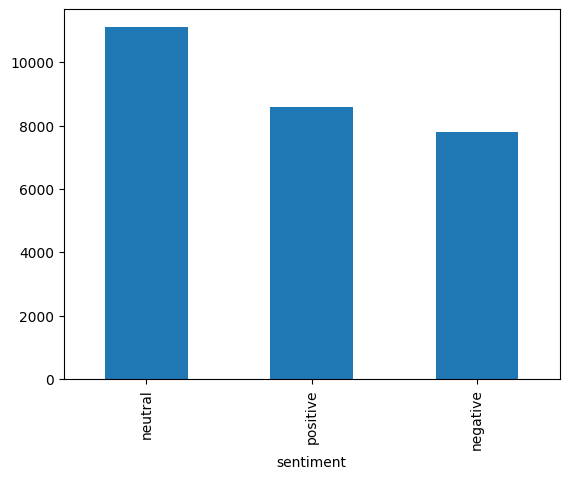

In [186]:
data['sentiment'].value_counts().plot(kind='bar')

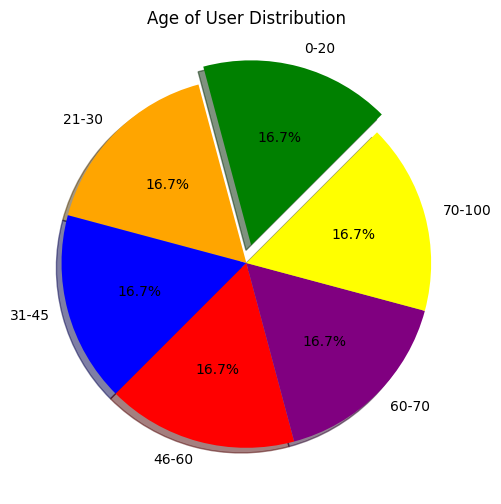

In [189]:
import matplotlib.pyplot as plt

# Get value counts
age_counts = data['Age of User'].value_counts()

# Generate explode list dynamically
explode = [0.1 if i == 0 else 0 for i in range(len(age_counts))]  # explode the largest slice

# Plot
plt.figure(figsize=(10, 6))
age_counts.plot(
    kind='pie',
    autopct='%.1f%%',
    shadow=True,
    colors=['green', 'orange', 'blue', 'red', 'purple', 'yellow'],  # Add more colors if needed
    startangle=45,
    explode=explode
)
plt.title('Age of User Distribution')
plt.ylabel('')  # Hides the default ylabel
plt.show()

# Working with text

In [191]:
data['text'][999]

' I`ve been unlocked for decades now...just not lucky, never have been.  Gottta make my own luck and that involves $$$$$'

# Cleaning steps
removing HTML Tags
extracting emojies # The pattern re.compile('(?::|;|=)(?:-)?(?:)|(|D|P)') is a regular expression used to match and extract emojis from a given text.
removing special chars,puntuation,sumbols
lower casing
removing stopwords
tokenization

In [194]:
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords

In [196]:
stopwords_set = set(stopwords.words('english'))
emoji_pattern = re.compile('(?::|;|=)(?:-)?(?:\)|\(|D|P)')

def preprocessing(text):
    text = re.sub('<[^>]*>', '', text)
    emojis = emoji_pattern.findall(text)
    text = re.sub('[\W+]', ' ', text.lower()) + ' '.join(emojis).replace('-', '')

    prter = PorterStemmer()
    text = [prter.stem(word) for word in text.split() if word not in stopwords_set]

    return " ".join(text)

<>:2: SyntaxWarning: invalid escape sequence '\)'
<>:7: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\)'
<>:7: SyntaxWarning: invalid escape sequence '\W'
C:\Users\umesh\AppData\Local\Temp\ipykernel_4320\48343199.py:2: SyntaxWarning: invalid escape sequence '\)'
  emoji_pattern = re.compile('(?::|;|=)(?:-)?(?:\)|\(|D|P)')
C:\Users\umesh\AppData\Local\Temp\ipykernel_4320\48343199.py:7: SyntaxWarning: invalid escape sequence '\W'
  text = re.sub('[\W+]', ' ', text.lower()) + ' '.join(emojis).replace('-', '')


In [198]:
preprocessing('this is my tags <h1> :) <p>helo world<p> <div> <div> </h2>')

'tag helo world :)'

In [200]:
data['text']

0                      I`d have responded, if I were going
1            Sooo SAD I will miss you here in San Diego!!!
2                                my boss is bullying me...
3                           what interview! leave me alone
4         Sons of ****, why couldn`t they put them on t...
                               ...                        
27476     wish we could come see u on Denver  husband l...
27477     I`ve wondered about rake to.  The client has ...
27478     Yay good for both of you. Enjoy the break - y...
27479                           But it was worth it  ****.
27480       All this flirting going on - The ATG smiles...
Name: text, Length: 27481, dtype: object

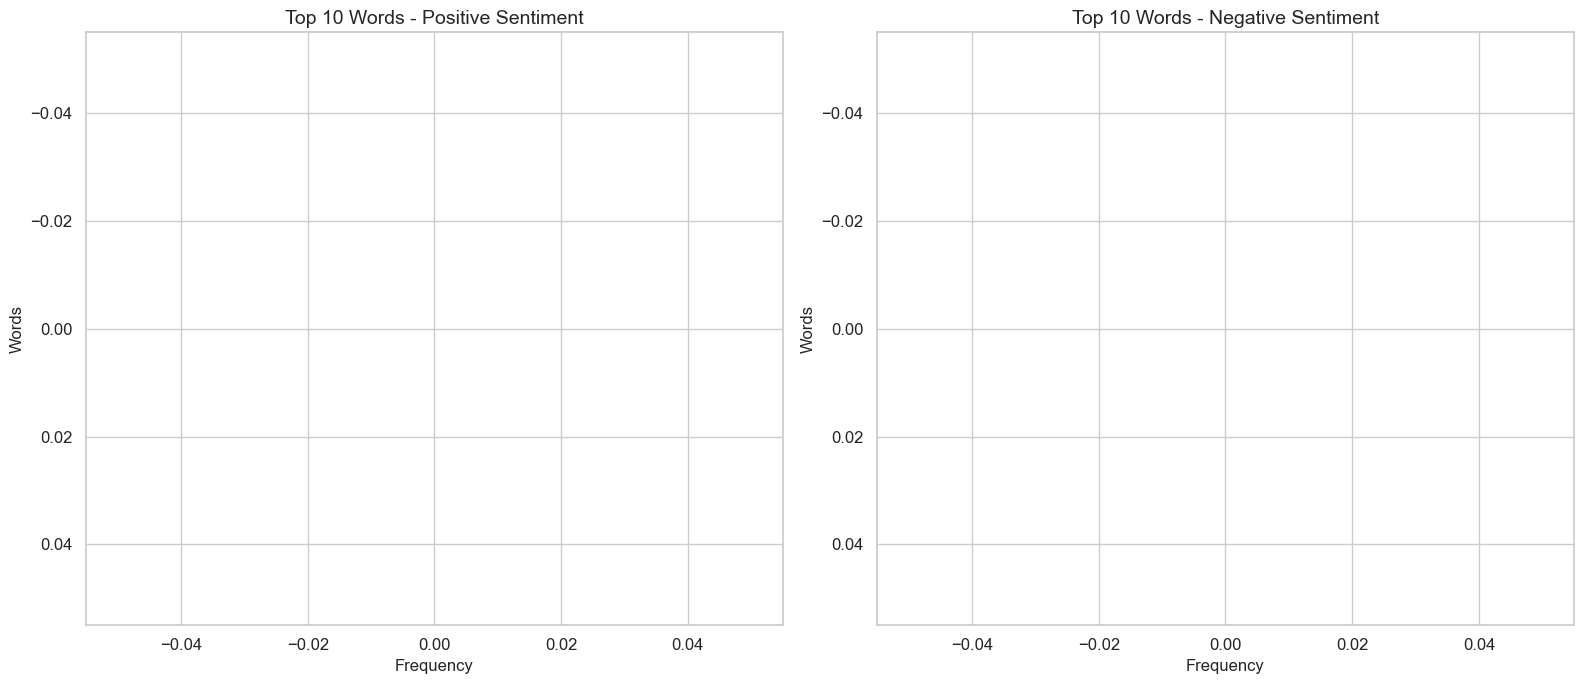

In [228]:
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

# Use a modern seaborn theme
sns.set(style="whitegrid")

# Filter data
positivedata = data[data['sentiment'] == 1]['text'].dropna()
negdata = data[data['sentiment'] == 0]['text'].dropna()

# Tokenize and count words
positivedata_words = ' '.join(positivedata).lower().split()
negdata_words = ' '.join(negdata).lower().split()

positivedata_word_counts = Counter(positivedata_words).most_common(10)
negdata_word_counts = Counter(negdata_words).most_common(10)

# Create the figure
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Colors
positive_colors = sns.color_palette("Greens", len(positivedata_word_counts))
negative_colors = sns.color_palette("Reds", len(negdata_word_counts))

# Plot positive words
axes[0].barh(
    [word for word, _ in positivedata_word_counts],
    [count for _, count in positivedata_word_counts],
    color=positive_colors
)
axes[0].set_title('Top 10 Words - Positive Sentiment', fontsize=14)
axes[0].invert_yaxis()  # Highest on top

# Plot negative words
axes[1].barh(
    [word for word, _ in negdata_word_counts],
    [count for _, count in negdata_word_counts],
    color=negative_colors
)
axes[1].set_title('Top 10 Words - Negative Sentiment', fontsize=14)
axes[1].invert_yaxis()

# General plot settings
for ax in axes:
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Words')
    ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

# TF-IDF Vectorizer to conert the raew documents into feature matrix

In [239]:
y = data['sentiment'].values

In [241]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [243]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    strip_accents=None,
    lowercase=False,
    preprocessor=None,
    use_idf=True,
    norm='l2',
    smooth_idf=True
)

# Training Machine Learning Model for Sentiment Analysis
Now to train a machine learning model I will split the data into 50 percent training and 50 percent test sets:

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,random_state=1,test_size=0.5,shuffle=False)

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
clf=LogisticRegressionCV(cv=6,scoring='accuracy',random_state=0,n_jobs=-1,verbose=3,max_iter=500).fit(X_train,y_train)
y_pred = clf.predict(X_test)

# Acuuracy

In [316]:
from sklearn import metrics

# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.6722707423580786


In [308]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Assuming 'data' is your dataframe

# Drop rows where 'text' column has NaN values
data = data.dropna(subset=['text'])

# Define X and y
X = data['text']  # Text data for features
y = data['sentiment']  # Sentiment (target labels)

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(lowercase=True, stop_words='english')
X_tfidf = tfidf.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, random_state=1, test_size=0.5, shuffle=False)

# Logistic Regression with Cross-Validation
clf = LogisticRegressionCV(cv=6, scoring='accuracy', random_state=0, n_jobs=-1, verbose=3, max_iter=500)

# Train the model
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Optionally, you can print the results
print("Predictions:", y_pred)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:   26.1s remaining:   26.1s


Predictions: ['neutral' 'neutral' 'positive' ... 'positive' 'positive' 'positive']


[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:   26.7s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:   26.7s finished


# Pickles files

In [324]:
import pickle
pickle.dump(clf,open('clf.pkl','wb'))
pickle.dump(tfidf,open('tfidf.pkl','wb'))

# predictions

In [327]:
def prediction(comment):
    preprocessed_comment = preprocessing(comment)
    comment_list = [preprocessed_comment]  # Wrap the preprocessed comment in a list
    comment_vector = tfidf.transform(comment_list)
    prediction = clf.predict(comment_vector)[0]
    return prediction



prediction = prediction('one cerebr insight movi ever seen script languag costum sceneri plot charact etc suprem bore watch intens even listen movi work mani time lost count scarlett age grace acquir wisdom beyond year end movi take tara ireland famili origin see result anoth civil war play time irish english movi depict doubl standard men time man still respect girlfriend whore woman mere seen privat place man societi accus improprieti cours scarlett alway think outsid box break rule necessari creat need chang help peopl surviv scarlett beauti definit bone strength self esteem wisdom grow age rememb line confront much plate tomorrow anoth day way carri determin courag learn experi good movi show daughter teach woman import respect men especi handsom one two side may treat woman differ depend act respect attract woman need learn movi teach movi like therapi better gone wind second part take place ireland anyon irish decent cherish sceneri peopl scarlett charact within')

In [329]:
if prediction ==1:
    print("positive comment")
else:
    print("negative comment")

negative comment


In [331]:
data['text'][9995]

'Just got bullied by Dillah.  HELP!'

In [333]:
data['text'][0]

' I`d have responded, if I were going'